In [1]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv(
    "DP590_IFGA_Welding_Analytics_Dataset.csv"
)

print(df.head())

   Sample_ID  Current_kA  Weld_Time_Cycles  Electrode_Force_kN  \
0          1         8.6                10                 3.0   
1          2         8.9                20                 2.0   
2          3         7.3                20                 2.0   
3          4         7.9                18                 4.0   
4          5         7.0                18                 3.0   

   Resistance_mOhm  Heat_Input  Nugget_Diameter_mm  Tensile_Strength_kN  \
0            0.195      144.22                4.39                 3.66   
1            0.215      340.60                5.05                 3.98   
2            0.214      228.08                4.77                 4.03   
3            0.197      221.31                4.92                 4.18   
4            0.197      173.75                4.34                 3.84   

  Failure_Mode Expulsion  
0           IF        No  
1           IF        No  
2           IF        No  
3           IF        No  
4           IF   

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sample_ID            50 non-null     int64  
 1   Current_kA           50 non-null     float64
 2   Weld_Time_Cycles     50 non-null     int64  
 3   Electrode_Force_kN   50 non-null     float64
 4   Resistance_mOhm      50 non-null     float64
 5   Heat_Input           50 non-null     float64
 6   Nugget_Diameter_mm   50 non-null     float64
 7   Tensile_Strength_kN  50 non-null     float64
 8   Failure_Mode         50 non-null     object 
 9   Expulsion            50 non-null     object 
dtypes: float64(6), int64(2), object(2)
memory usage: 4.0+ KB
None


In [7]:
#STATISTICAL SUMMARY
print(df.describe())

       Sample_ID  Current_kA  Weld_Time_Cycles  Electrode_Force_kN  \
count   50.00000   50.000000         50.000000           50.000000   
mean    25.50000    8.044000         15.540000            2.890000   
std     14.57738    0.869004          4.086863            0.744298   
min      1.00000    6.600000         10.000000            2.000000   
25%     13.25000    7.300000         10.500000            2.125000   
50%     25.50000    8.000000         15.000000            2.750000   
75%     37.75000    8.600000         20.000000            3.500000   
max     50.00000    9.800000         20.000000            4.000000   

       Resistance_mOhm  Heat_Input  Nugget_Diameter_mm  Tensile_Strength_kN  
count        50.000000   50.000000           50.000000            50.000000  
mean          0.205280  207.935400            4.661600             3.917000  
std           0.016613   71.729096            0.409501             0.285194  
min           0.180000   91.580000            3.700000   

In [8]:
#What is the average tensile strength?
avg_strength = df["Tensile_Strength_kN"].mean()

print(avg_strength)

3.917


In [9]:
#What is the average nugget diameter?
avg_nugget = df[
    "Nugget_Diameter_mm"
].mean()

print(avg_nugget)

4.6616


In [10]:
#Which parameter affects tensile strength the most?
corr_matrix = df.corr(
    numeric_only=True
)

print(corr_matrix)

                     Sample_ID  Current_kA  Weld_Time_Cycles  \
Sample_ID             1.000000    0.075074         -0.047102   
Current_kA            0.075074    1.000000         -0.057969   
Weld_Time_Cycles     -0.047102   -0.057969          1.000000   
Electrode_Force_kN   -0.001411    0.037611         -0.057229   
Resistance_mOhm      -0.082837   -0.119472          0.074375   
Heat_Input           -0.005089    0.529097          0.760159   
Nugget_Diameter_mm    0.018598    0.714942          0.599069   
Tensile_Strength_kN   0.092165    0.785711          0.285247   

                     Electrode_Force_kN  Resistance_mOhm  Heat_Input  \
Sample_ID                     -0.001411        -0.082837   -0.005089   
Current_kA                     0.037611        -0.119472    0.529097   
Weld_Time_Cycles              -0.057229         0.074375    0.760159   
Electrode_Force_kN             1.000000        -0.308567   -0.109704   
Resistance_mOhm               -0.308567         1.000000    0.2

In [12]:
#Correlation with strength
print(
corr_matrix[
"Tensile_Strength_kN"
].sort_values(
ascending=False
)
)

Tensile_Strength_kN    1.000000
Nugget_Diameter_mm     0.811389
Current_kA             0.785711
Heat_Input             0.659361
Weld_Time_Cycles       0.285247
Sample_ID              0.092165
Electrode_Force_kN    -0.043408
Resistance_mOhm       -0.146613
Name: Tensile_Strength_kN, dtype: float64


In [13]:
#Does current increase strength?
df.groupby(
"Current_kA"
)["Tensile_Strength_kN"].mean()

Current_kA
6.6    3.530000
6.7    3.600000
6.8    3.555000
6.9    3.425000
7.0    3.685000
7.2    3.760000
7.3    3.816667
7.4    3.930000
7.5    3.700000
7.7    3.850000
7.8    3.785000
7.9    4.180000
8.0    3.824000
8.1    3.840000
8.2    4.280000
8.3    3.750000
8.4    4.046000
8.5    3.990000
8.6    3.936667
8.7    4.226667
8.8    4.320000
8.9    3.980000
9.4    4.185000
9.6    4.186667
9.8    4.640000
Name: Tensile_Strength_kN, dtype: float64

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

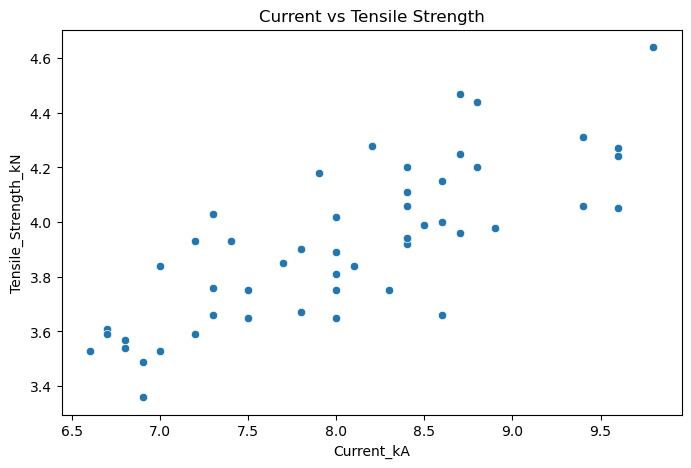

In [15]:
#Does current increase strength -- visualization?
plt.figure(figsize=(8,5))

sns.scatterplot(
x="Current_kA",
y="Tensile_Strength_kN",
data=df
)

plt.title(
"Current vs Tensile Strength"
)

plt.show()

In [16]:
#Result= Strength increases with current up to an optimum value.

In [17]:
#Does heat input increase nugget diameter?
df[
[
"Heat_Input",
"Nugget_Diameter_mm"
]
].corr()

,Heat_Input,Nugget_Diameter_mm
Heat_Input,1.000000,0.891005
Nugget_Diameter_mm,0.891005,1.000000


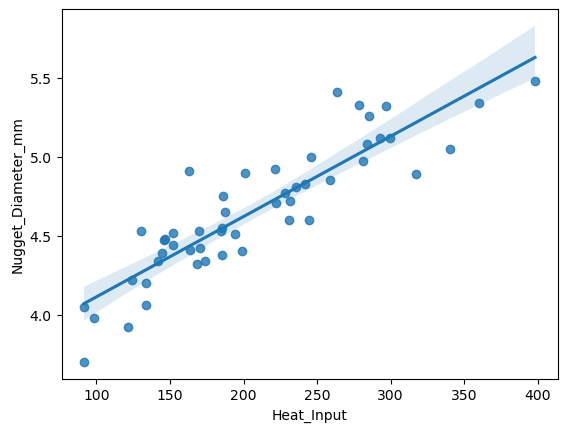

In [18]:
#visulization
sns.regplot(
x="Heat_Input",
y="Nugget_Diameter_mm",
data=df
)

plt.show()

In [19]:
#Result--> Higher heat input produces larger nuggets.

In [20]:
#What percentage of welds are PF?
pf_percentage = (
df["Failure_Mode"]
.eq("PF")
.mean()
*100
)

print(pf_percentage)

12.0


In [21]:
#What percentage of welds show expulsion?
expulsion_rate = (
df["Expulsion"]
.eq("Yes")
.mean()
*100
)

print(expulsion_rate)

0.0


In [22]:
#Find the Best Weld
best_weld = df[
(df["Failure_Mode"]=="PF")
&
(df["Expulsion"]=="No")
]

best_weld.sort_values(
"Tensile_Strength_kN",
ascending=False
).head(1)

,Sample_ID,Current_kA,Weld_Time_Cycles,Electrode_Force_kN,Resistance_mOhm,Heat_Input,Nugget_Diameter_mm,Tensile_Strength_kN,Failure_Mode,Expulsion
23,24,9.8,15,2.5,0.183,263.63,5.41,4.64,PF,No


In [23]:
#Standard Deviation of Strength
std_strength = np.std(
df["Tensile_Strength_kN"]
)

print(std_strength)

0.28232782363769954


In [24]:
#Interpretation=Lower value = stable process

In [25]:
#Welding Window Analysis
optimal = df[
(df["Failure_Mode"]=="PF")
&
(df["Expulsion"]=="No")
]

optimal.describe()

,Sample_ID,Current_kA,Weld_Time_Cycles,Electrode_Force_kN,Resistance_mOhm,Heat_Input,Nugget_Diameter_mm,Tensile_Strength_kN
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,28.833333,9.000000,19.166667,2.750000,0.202500,313.763333,5.356667,4.310000
std,11.391517,0.562139,2.041241,0.821584,0.021778,53.167204,0.077115,0.208614
min,16.000000,8.400000,15.000000,2.000000,0.180000,263.630000,5.260000,4.060000
25%,23.250000,8.700000,20.000000,2.125000,0.186250,280.350000,5.322500,4.210000
50%,25.000000,8.750000,20.000000,2.500000,0.199000,290.880000,5.335000,4.245000
75%,33.500000,9.400000,20.000000,3.250000,0.212500,344.385000,5.392500,4.415000
max,48.000000,9.800000,20.000000,4.000000,0.238000,398.130000,5.480000,4.640000


In [26]:
#Ranking Parameters by Importance 
corr_matrix = (
df.corr(
numeric_only=True
)
[
"Tensile_Strength_kN"
]
.abs()
.sort_values(
ascending=False
)
)

print(corr_matrix)

Tensile_Strength_kN    1.000000
Nugget_Diameter_mm     0.811389
Current_kA             0.785711
Heat_Input             0.659361
Weld_Time_Cycles       0.285247
Resistance_mOhm        0.146613
Sample_ID              0.092165
Electrode_Force_kN     0.043408
Name: Tensile_Strength_kN, dtype: float64


In [27]:
#Can we predict strength?
from sklearn.linear_model import LinearRegression

X = df[
[
"Current_kA",
"Weld_Time_Cycles",
"Electrode_Force_kN",
"Heat_Input",
"Nugget_Diameter_mm"
]
]

y = df[
"Tensile_Strength_kN"
]

model = LinearRegression()

model.fit(X,y)

print(
model.coef_
)

[ 0.1929154   0.01642853 -0.03833749 -0.00128296  0.37603536]


In [28]:
new_weld = [[
8.5,
15,
3,
220,
6
]]

prediction = model.predict(
new_weld
)

print(prediction)


[4.47968823]


C:\Users\piu chatterjee\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


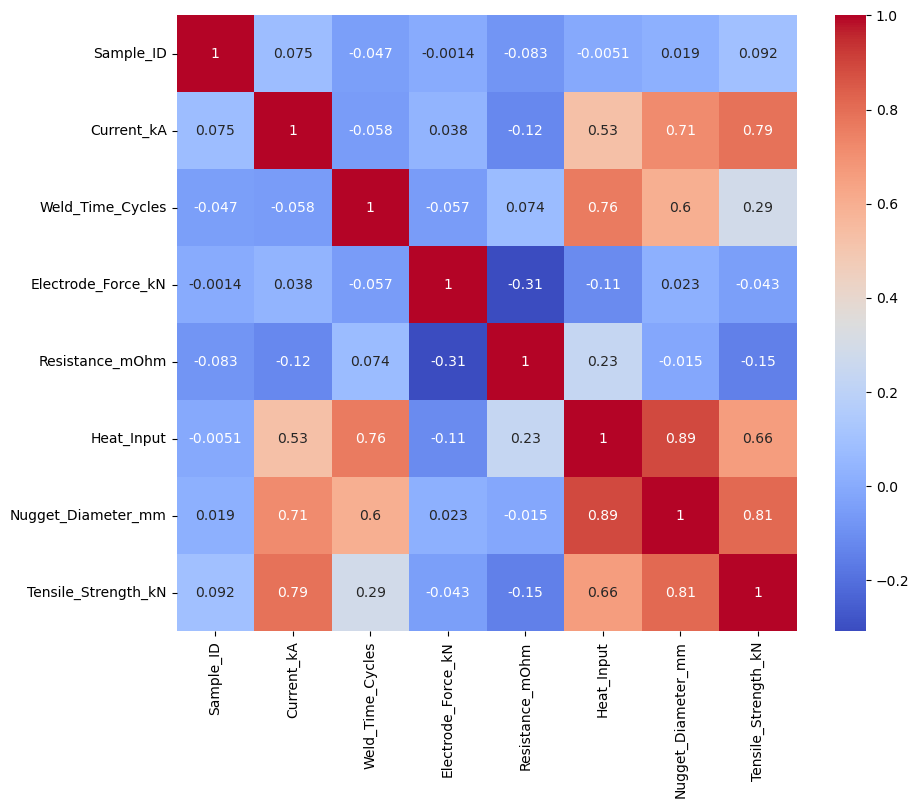

In [29]:
#Heatmap Visualization
plt.figure(
figsize=(10,8)
)

sns.heatmap(
df.corr(
numeric_only=True
),
annot=True,
cmap="coolwarm"
)

plt.show()

REPORT ANALYSIS
